In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from scipy.ndimage import rank_filter

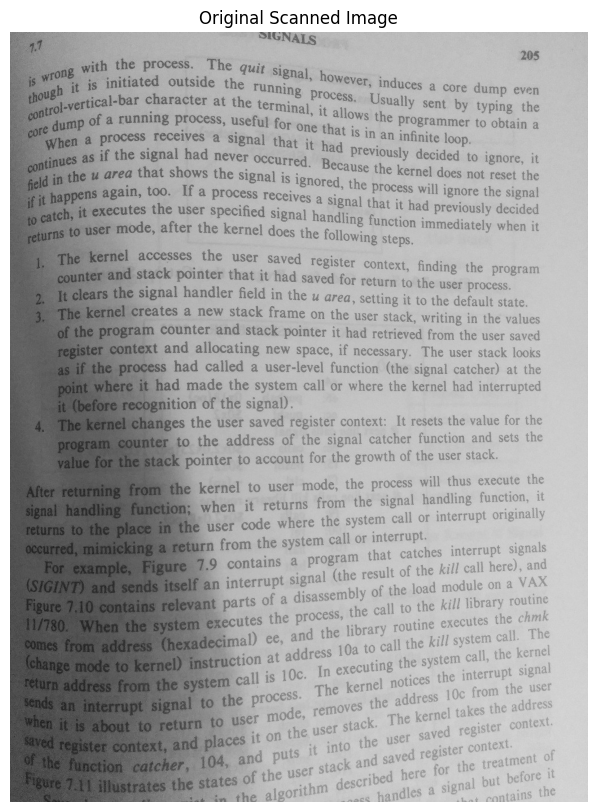

In [7]:
img_path = './Input_Image/ScannedText.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8, 10))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Scanned Image")
plt.axis('off')
plt.show()

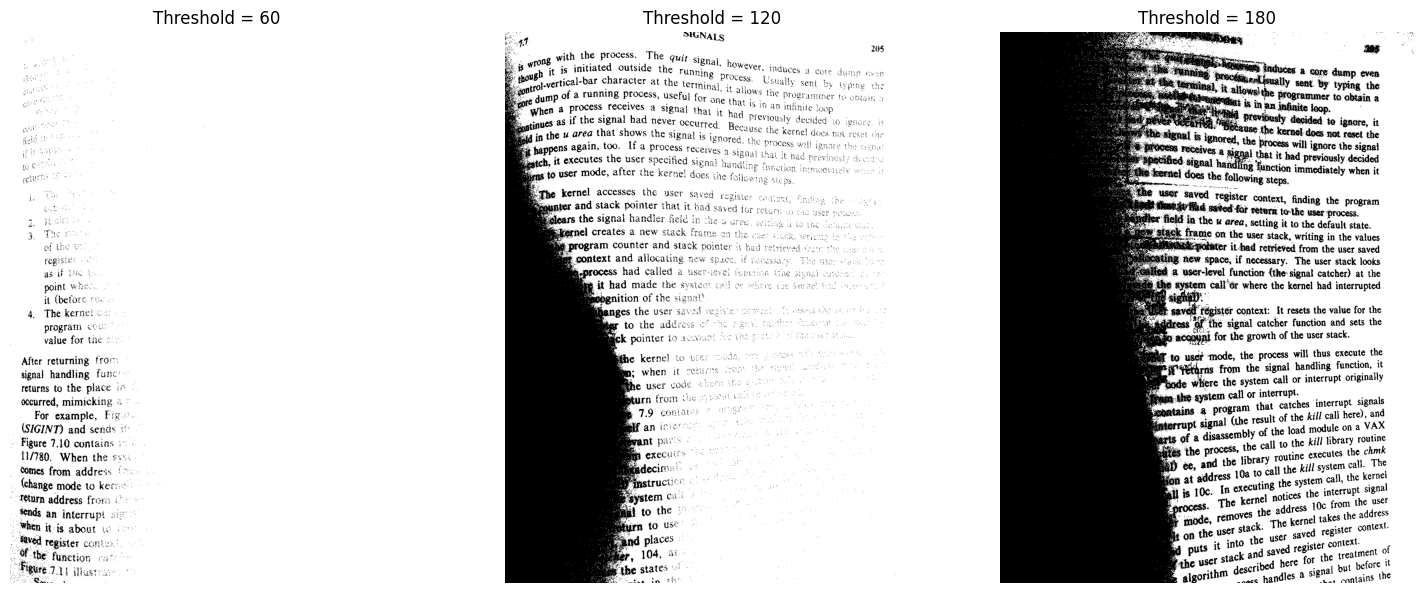

In [8]:
thresholds = [60, 120, 180]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, T in enumerate(thresholds):
    ret, thresh_img = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)
    save_path = os.path.join('./Output_Images/Part_1', f'thresh_{T}.jpg')
    cv2.imwrite(save_path, thresh_img)
    
    axes[i].imshow(thresh_img, cmap='gray')
    axes[i].set_title(f'Threshold = {T}')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

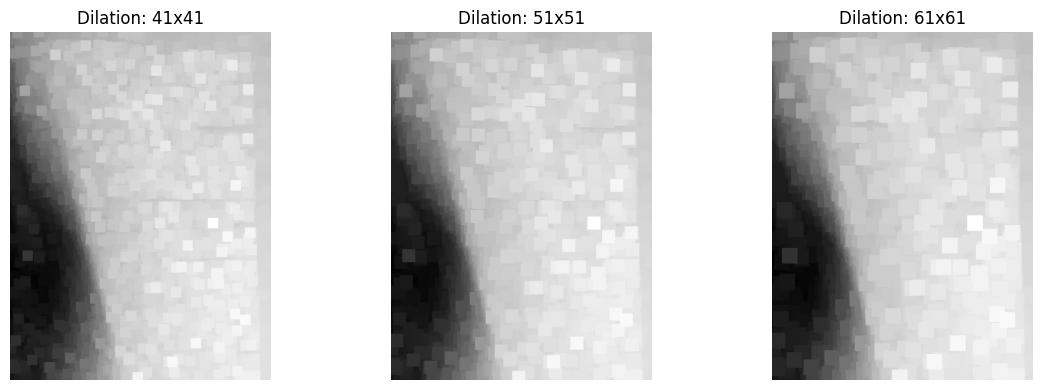

In [9]:
kernel_sizes = [41, 51, 61]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
dilated_images = {}

for i, k in enumerate(kernel_sizes):
    kernel = np.ones((k, k), np.uint8)
    
    dilated = cv2.dilate(img, kernel, borderType=cv2.BORDER_CONSTANT, borderValue=0)

    save_path = os.path.join('./Output_Images/Part_2', f'dilated_{k}x{k}.jpg')
    cv2.imwrite(save_path, dilated)
    
    dilated_images[k] = dilated
    
    axes[i].imshow(dilated, cmap='gray')
    axes[i].set_title(f'Dilation: {k}x{k}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

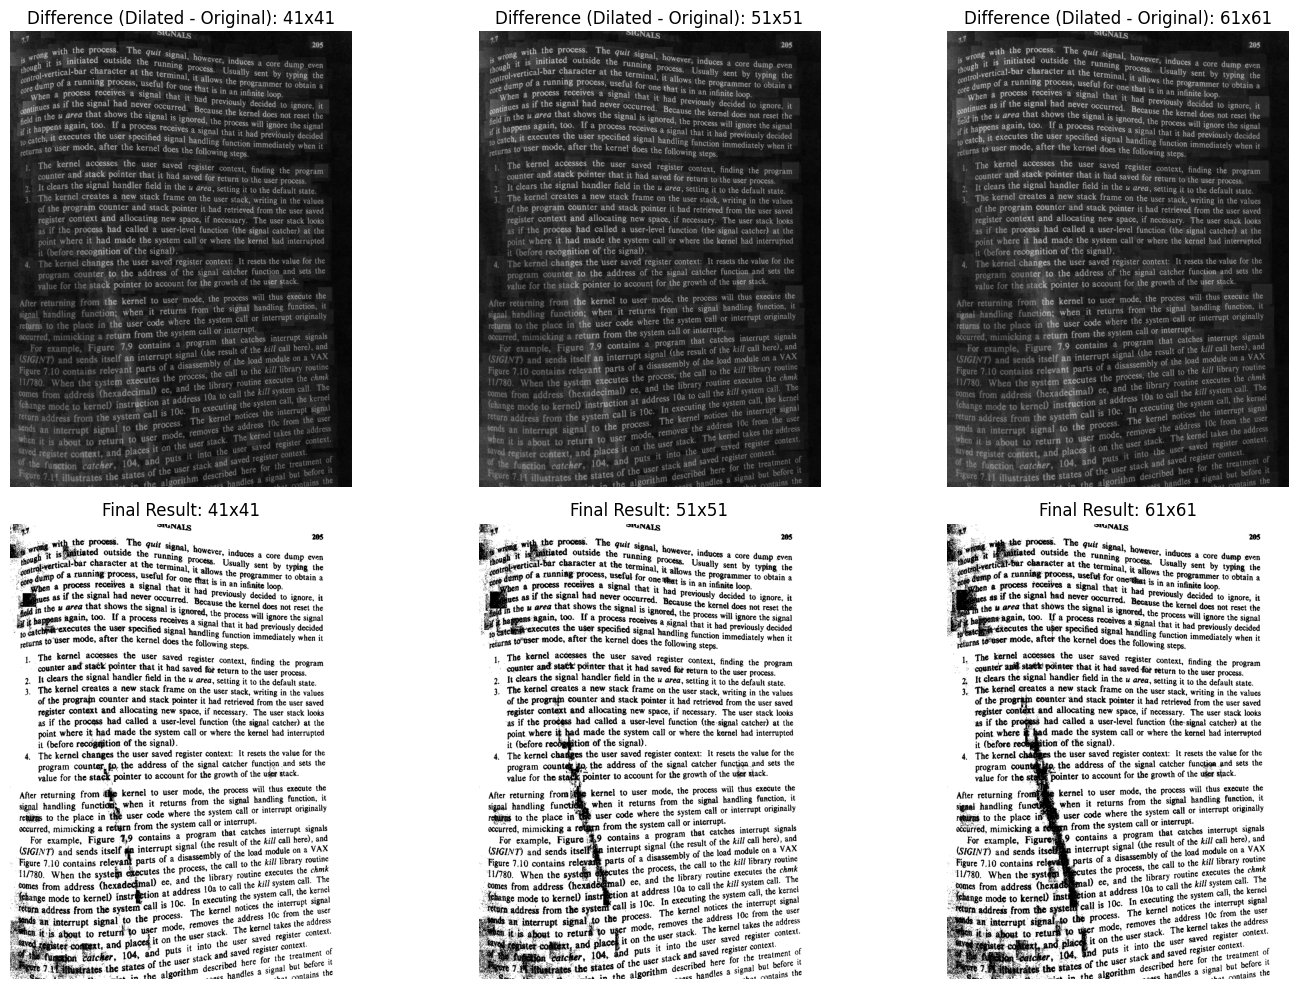

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

best_threshold = 40

for i, k in enumerate(kernel_sizes):
    diff_img = cv2.subtract(dilated_images[k], img)
    
    cv2.imwrite(os.path.join('./Output_Images/Part_3', f'diff_{k}x{k}.jpg'), diff_img)
    
    ret, thresh_img = cv2.threshold(diff_img, best_threshold, 255, cv2.THRESH_BINARY)
    
    final_result = cv2.bitwise_not(thresh_img)
    
    cv2.imwrite(os.path.join('./Output_Images/Part_3', f'final_thresh_{k}x{k}.jpg'), final_result)
    
    axes[0, i].imshow(diff_img, cmap='gray')
    axes[0, i].set_title(f'Difference (Dilated - Original): {k}x{k}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(final_result, cmap='gray')
    axes[1, i].set_title(f'Final Result: {k}x{k}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [19]:
k = 51

start_time = time.time()
kernel = np.ones((k, k), np.uint8)
dilated = cv2.dilate(img, kernel, borderType=cv2.BORDER_CONSTANT, borderValue=0)
dilation_time = time.time() - start_time

start_time = time.time()
rank_img = rank_filter(img, rank=-7, size=(k, k))
rank_time = time.time() - start_time

diff_rank = cv2.subtract(rank_img, img)
best_threshold = 40
ret, thresh_rank = cv2.threshold(diff_rank, best_threshold, 255, cv2.THRESH_BINARY)
final_rank = cv2.bitwise_not(thresh_rank)

cv2.imwrite(os.path.join('./Output_Images/Part_4', f'rank_{k}x{k}.jpg'), rank_img)
cv2.imwrite(os.path.join('./Output_Images/Part_4', f'diff_rank_{k}x{k}.jpg'), diff_rank)
cv2.imwrite(os.path.join('./Output_Images/Part_4', f'final_thresh_rank_{k}x{k}.jpg'), final_rank)

True

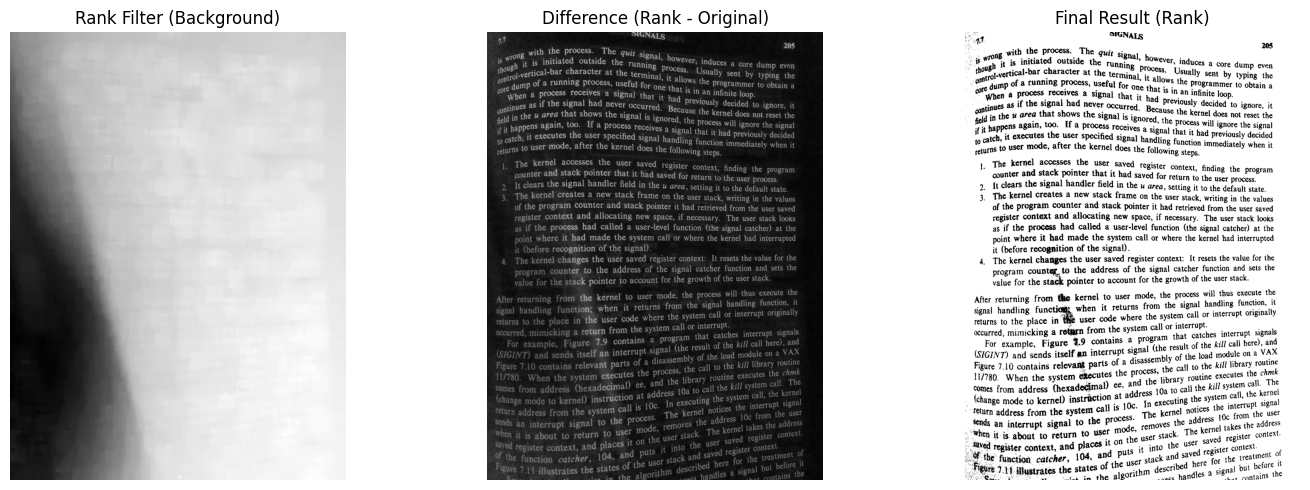

Dilation Execution Time: 0.0020 seconds
Rank Filter Execution Time: 20.7522 seconds


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rank_img, cmap='gray')
axes[0].set_title(f"Rank Filter (Background)")
axes[0].axis('off')

axes[1].imshow(diff_rank, cmap='gray')
axes[1].set_title(f"Difference (Rank - Original)")
axes[1].axis('off')

axes[2].imshow(final_rank, cmap='gray')
axes[2].set_title(f"Final Result (Rank)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Dilation Execution Time: {dilation_time:.4f} seconds")
print(f"Rank Filter Execution Time: {rank_time:.4f} seconds")